In [1]:
import pandas as pd
import numpy as np
import pickle
import keras
from sklearn.metrics import r2_score, mean_squared_error, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt # 그래프 그리는 라이브러리
import matplotlib

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

In [2]:
PAST_STEP = 36 # 관측 데이터 사용량 (10분단위, 6시간, 36 STEP)
FORECAST_STEP = 72 # 예보 데이터 사용량 ( 10분단위, 12시간, 72 STEP )

# 1 / 3 (시간)
time = 3

if (time == 1) :
    # 1시간
    HOUR_STEP = 6
    TOTAL_STEP = 6
elif (time == 3) :
    #3시간
    HOUR_STEP = 18
    TOTAL_STEP = 18
else :
    print( "오류 :1시간 3시간만 하는중 ")

# 유량 예측 모델일 시 이 변수 사용
# DG_OUTPUT_COL = ['서울시(대곡교)_FW']
# GN_OUTPUT_COL = ['성남시(궁내교)_FW']
DG_WL_COL = ['서울시(대곡교)_WL']
GN_WL_COL = ['성남시(궁내교)_WL']
# INPUT1_COL = [
#                 '성남시(한국학중앙연구원)','성남시(대장동)', '성남시(구미초교)',
#                 '서울시(대곡교)',  '성남시(성남북초교)', '광주시(남한산초교)',
#                 '궁내교_Ti', '대곡교_Ti', '성남시(궁내교)_FW', '서울시(대곡교)_FW' ]

# # 수위 예측 모델일 시 이 변수 사용
DG_OUTPUT_COL = ['서울시(대곡교)_WL']
GN_OUTPUT_COL = ['성남시(궁내교)_WL']
INPUT1_COL = [
                '성남시(한국학중앙연구원)','성남시(대장동)', '성남시(구미초교)',
                '서울시(대곡교)',  '성남시(성남북초교)', '광주시(남한산초교)',
                '궁내교_Ti', '대곡교_Ti', '성남시(궁내교)_WL', '서울시(대곡교)_WL' ]

INPUT2_COL = [
                '성남시(한국학중앙연구원)','성남시(대장동)', '성남시(구미초교)',
                '서울시(대곡교)',  '성남시(성남북초교)', '광주시(남한산초교)',
                '궁내교_Ti', '대곡교_Ti', 
            ]

testdata_dir = './testdata'

testdata_200802 = f'{testdata_dir}/72step/20200802.csv'
testdata_220916 = f'{testdata_dir}/72step/20220916.csv'
testdata_230711 = f'{testdata_dir}/72step/20230711_044.csv'
testdata_240723 = f'{testdata_dir}/72step/20240723.csv'
testdata_250716 = f'{testdata_dir}/72step/250716_1700.xlsx'
testdata_250814 = f'{testdata_dir}/72step/250814_0500.xlsx'

testdata_200802 = pd.read_csv(testdata_200802) 
testdata_220916 = pd.read_csv(testdata_220916) 
testdata_230711 = pd.read_csv(testdata_230711) 
testdata_240723 = pd.read_csv(testdata_240723) 
testdata_250716 = pd.read_excel(testdata_250716) # 250716 테스트 데이터 Dataframe
testdata_250814 = pd.read_excel(testdata_250814) # 250814 테스트 데이터 Dataframe

# dataset_list = [testdata_220712, testdata_230711, testdata_250716, testdata_250814]

#worker = "swkim"
worker = "jmlee"

# # 모델 저장 경로 
# dir_model = f'./model_stage/{worker}/model_sungnam_{target_key}'

# # 스케일러 저장 경로
# scalerfile = f'./model_stage/{worker}/scaler_{target_key}.pkl'

# # 모델 저장 경로 
# dir_model = f'./model_stage/model_{target_key}36_wl'

# # 스케일러 저장 경로
# scalerfile = f'./model_stage/scaler_{target_key}36_wl.pkl'

# ------------------------------------------------------------------ target_key
target_key = 'gn' # 궁내교
# target_key = 'dg' # 대곡교

TARGET_COL = DG_OUTPUT_COL if target_key == 'dg' else GN_OUTPUT_COL
WL_COL = DG_WL_COL if target_key == 'dg' else GN_WL_COL
Y_Min = 1.5 if target_key == 'dg' else 0.7
Y_Max = 5.5 if target_key == 'dg' else 3
# ------------------------------------------------------------------ 저장 경로
# 모델 저장 경로 
dir_model = f'./model_stage/model_{target_key}_20'

# 스케일러 저장 경로
scalerfile = f'./model_stage/scaler_{target_key}_20.pkl'

#스케일러 로드
with open(scalerfile, 'rb') as file:
    scaler_x = pickle.load(file)
    scaler_f = pickle.load(file)
    scaler_y = pickle.load(file)


In [3]:
model = keras.models.load_model(dir_model) # 모델 로드

In [4]:
import os

def make_input_data(df, n): 

    """
    input1: n ~ n+PAST_STEP (관측 입력)
    input2: n+PAST_STEP ~ n+2*PAST_STEP (예보 입력)
    output: n+PAST_STEP ~ n+2*PAST_STEP (미래 관측 타겟)
    """
    
    # 입력데이터 생성
    df_input1 = df.iloc[n:n+PAST_STEP]
    df_input1 = df_input1[INPUT1_COL]
    input1 = np.array(df_input1)
    
    df_input2 = df.iloc[n+PAST_STEP:n+2*PAST_STEP]
    df_output = df_input2[TARGET_COL]
    df_input2 = df_input2[INPUT2_COL]
    
    input2 = np.array(df_input2)
    output = np.array(df_output).flatten()
    
    
    input1 =  scaler_x.transform(input1) # 입력자료 1(관측) 데이터 스케일링
    input2 =  scaler_f.transform(input2) # 입력자료 2(예보) 데이터 스케일링

    input1 = input1.reshape(1, input1.shape[-2], input1.shape[-1])
    input2 = input2.reshape(1, input2.shape[-2], input2.shape[-1])
    
    return input1, input2, output
    
def HQCurve(waterlevel):
    # 수위로 유량을 구하는 곡선식 (23.11 ~ 부터 적용 )
    if waterlevel >= 0.54 and waterlevel <= 1.31 :
        return 40.769 * (waterlevel - 0.540) ** 1.728
    elif waterlevel > 1.31 and waterlevel <= 2.42 :
        return 13.779 * ( waterlevel - 0.040 ) ** 2.649
    else :
        return 22.778 * ( h - 0.400 ) ** 2.552
        
def QHCurve(flow):
    # 유량으로 수위를 구하는 곡선식 (23.11 ~ 부터 적용 )
    if flow >= HQCurve(0.54) and flow <= HQCurve(1.31) :
        return  0.540 + ( flow / 40.769 ) ** (1/1.728)
    elif flow > HQCurve(1.31) and flow <= HQCurve(2.42) :
        return 0.040 + ( flow / 13.779 ) ** (1/2.649)
    else :
        return 0.400 + ( flow / 22.778 ) ** (1/2.552)


def drawCorrectionGraph(y_real, y_pred, pred_type):
    # 예측 결과 비교 그래프
    # y_real : 관측, y_pred : 예측

    plt.figure(figsize=(15, 8))

    start = len(y_real) - len(y_pred)     # 보통 72-36=36
    plt.axvline(start-0.5, linestyle="--", linewidth=1, color="gray")
    plt.plot(np.arange(len(y_real)), y_real, 'blue')
    plt.plot(np.arange(start, start + len(y_pred)), y_pred, 'orange')

    # plt.axis
    plt.ylim(Y_Min, Y_Max)
    plt.legend([f'pred start', f'obs', f'pred'], loc='upper left')
    plt.title(f'Tancheon {pred_type} Prediction Result ')
    plt.xlabel('step')
    plt.ylabel(f'{pred_type}(m)')
    
    plt.tight_layout()
    plt.show()


def drawRainGraph(df, target_key):
    # 강우 그래프

    if target_key == 'gn':
        col = '궁내교_Ti'
        title = '궁내교 Ti'
        y_max = 22
    elif target_key == 'dg':
        col = '대곡교_Ti'
        title = '대곡교 Ti'
        y_max = 19
    else:
        raise ValueError("target_key must be 'gn' or 'dg'")

    x    = range(len(df))
    rain = df[col].values

    plt.figure(figsize=(15, 4))
    plt.bar(x, -rain, width=0.5, label=col)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.xlabel('step')
    plt.ylabel('Ti (mm)')
    plt.ylim(-y_max, 0)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [5]:
# ------------------------------------------------------------------ testdata 선택
#  testdata_200802 , testdata_220916 , testdata_230711 , testdata_240723 , testdata_250716 , testdata_250814
data = testdata_200802 

In [6]:
obs_list  = []
pred_list = []

df = data

# n = 0 ~ 30 반복
for n in range(0, TOTAL_STEP):

    # make_input_data(df, n) 는 (input1, input2, output_true) 반환한다고 가정
    # - input1: (1, 36, n_features1)
    # - input2: (1, 72, n_features2) 혹은 (1, 72, ...)
    # - output_true: (72,)  (미래구간 실제 타겟, 역스케일 전/후는 코드에 맞춰서)

    sample  = make_input_data(df, n)
    if sample  is None:
        break

    input1, input2, output_true = sample 

    # ✅ (1) 1시간 뒤 "관측 수위" 저장
    # output_true가 추가로 역스케일이 필요하면 여기서 처리해줘야 함
    obs= output_true[HOUR_STEP]
    obs_list.append(obs)

    # ✅ (2) 모델 예측 수행
    y_pred = model.predict([input1, input2], verbose=0)   # 보통 (1, 72, 1)

    # ✅ (3) 역스케일링 (Scaler는 2D만 받으므로 reshape 필요)
    # (1, 72, 1) -> (1, 72) -> inverse -> (1, 72) -> (72,)
    y_pred = scaler_y.inverse_transform(y_pred.reshape(1, -1))[0]

    # ✅ (4) 1시간 뒤 "예측 수위" 저장
    pred = y_pred[HOUR_STEP]
    pred_list.append(pred)

# ===== 리스트 확인 =====
print("len(obs_list) :", obs_list)
print("len(pred_list):", pred_list)

# 필요하면 numpy array로 변환
obs_arr  = np.array(obs_list)
pred_arr = np.array(pred_list)

len(obs_list) : [1.24, 1.34, 1.4, 1.4, 1.42, 1.47]
len(pred_list): [1.3153493, 1.425581, 1.6505173, 1.6475357, 1.7459692, 1.7337202]


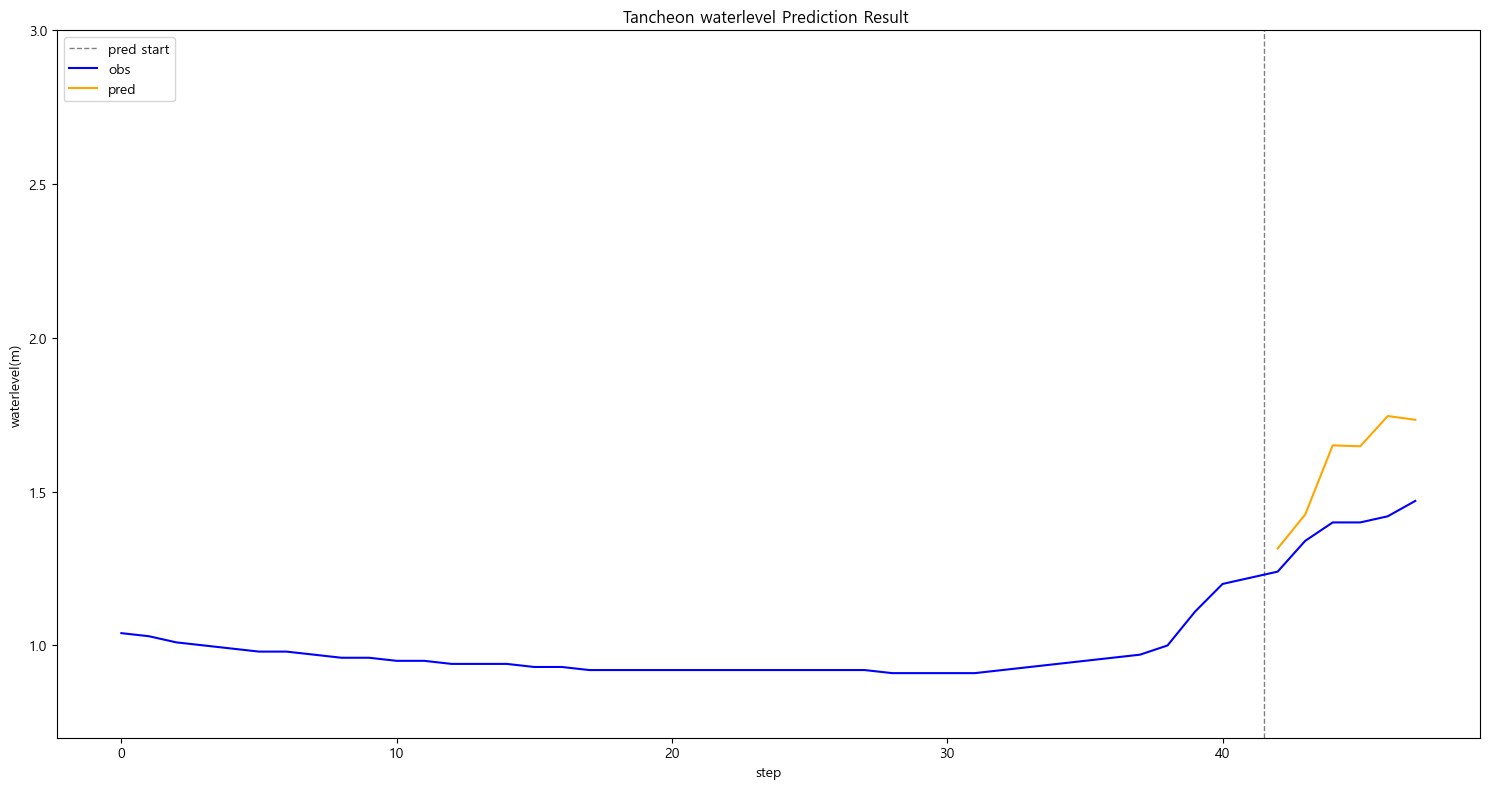

In [7]:
drawCorrectionGraph(data[WL_COL][:PAST_STEP+HOUR_STEP+TOTAL_STEP], pred_arr, 'waterlevel')

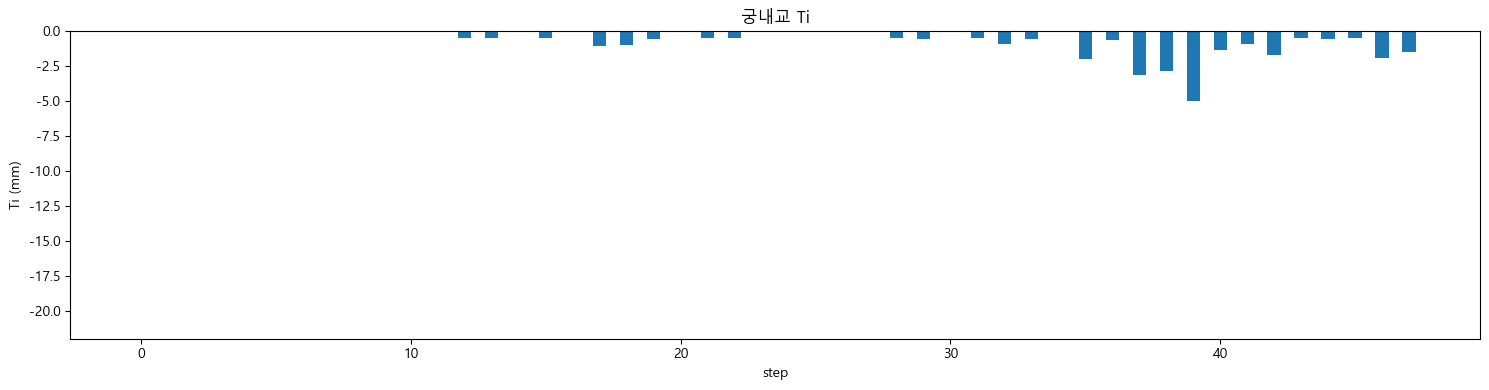

In [8]:
drawRainGraph(data[:PAST_STEP+HOUR_STEP+TOTAL_STEP], target_key)

In [9]:
# 메트릭 계산
r2 = r2_score(output_true, y_pred)
mse = mean_squared_error(output_true, y_pred)
mae = mean_absolute_error(output_true, y_pred)
rmse = np.sqrt(mse)

In [10]:
# 메트릭 계산 결과 출력
print(f'''
r2 : {r2}
mse : {mse}
mae : {mae}
rmse : {rmse}
''')


r2 : 0.6075621227077734
mse : 0.016579289087580235
mae : 0.09806401040818954
rmse : 0.12876058825424896

